P1.Preprocess data

In [1]:
import torch
import numpy as np
import random

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Chọn một con số bất kỳ, ví dụ 42
SEED = 42
set_seed(SEED)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
events=pd.read_csv('events.csv')
events.head(3)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN


In [4]:
def check_info(events):
  print('The size of events:',events.shape)
  print('The number of itemid unique:', events['itemid'].nunique())
  print('The number of visitorid unique:', events['visitorid'].nunique())
  print(events['event'].value_counts())

In [5]:
check_info(events)

The size of events: (2756101, 5)
The number of itemid unique: 235061
The number of visitorid unique: 1407580
event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64


In [6]:
print (events.isnull().sum())


timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


In [7]:
events.drop_duplicates(inplace=True)
check_info(events)

The size of events: (2755641, 5)
The number of itemid unique: 235061
The number of visitorid unique: 1407580
event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64


Explore the types of event

In [8]:
def distribution_of_the_events(events):
  eventsCounting=events['event'].value_counts()
  plt.figure(figsize=(8,5))
  sns.barplot(x=eventsCounting.index,y=eventsCounting.values, color='#c94169')
  plt.title('The ditribution of the events')
  plt.xlabel('Type of events')
  plt.ylabel('Number of events')
  plt.show()


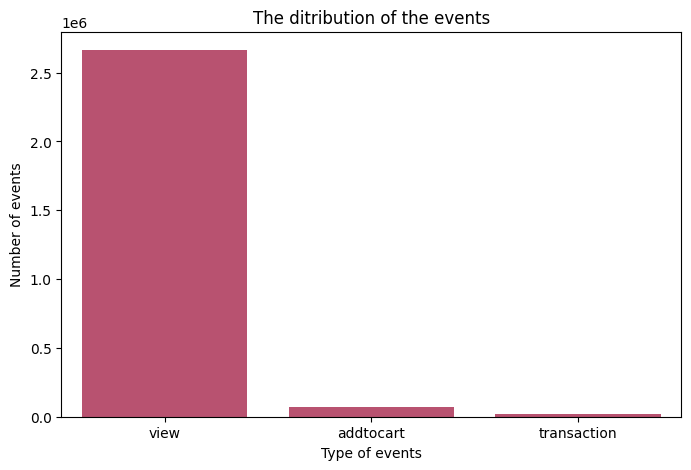

In [9]:
distribution_of_the_events(events)

In [10]:
def Calculate_sparsity_density(events):
    sparsity = 1 - len(events) / (events['visitorid'].nunique() * events['itemid'].nunique())
    density= len(events) / (events['visitorid'].nunique() * events['itemid'].nunique())
    print(f"Sparsity: {sparsity:.4f}")
    print(f"Density: {density:.4f}")
Calculate_sparsity_density(events)

Sparsity: 1.0000
Density: 0.0000


In [17]:
def distribution(events, x):
  if x=='itemid' or x=='visitorid':
    counts = events[x].value_counts()
    plt.figure(figsize=(10, 6))
    plt.hist(counts.values, bins=50, color='pink')
    if x =='itemid':
      plt.xlabel('Event with itemid')
      plt.ylabel('Number of itemid')
      plt.title('Distribution of itemid count by event')
    else:
      plt.xlabel('Event with visitorid')
      plt.ylabel('Number of visitorid')
      plt.title('Distribution of visitorid count by event')
    plt.yscale('log')
    plt.show()
  else:
    print('Error')

Explore itemid

In [21]:
def top10_low(events, x):
  if x=='itemid' or x=='visitorid':
    counts = events[x].value_counts()
    item_freq_count = counts.value_counts().sort_index()
    top10_low_freq = item_freq_count.head(10)
    plt.figure(figsize=(8, 5))
    bars = plt.bar(top10_low_freq.index.astype(str), top10_low_freq.values, color='#c94169')
    if x =='itemid':
      plt.xlabel('Event with itemid')
      plt.ylabel('Number of itemid')
      plt.title('Top 10 low distribution of itemid count by event')
    else:
      plt.xlabel('Event with visitorid')
      plt.ylabel('Number of visitorid')
      plt.title('Top 10 low distribution of visitorid count by event')
    plt.tight_layout()

    total_items = counts.shape[0]
    for i, bar in enumerate(bars):
        pct = 100 * top10_low_freq.values[i] / total_items
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.show()
  else:
    print('Error')

In [22]:
def statistic(event, x):
  if x=='itemid' or x=='visitorid':
    counts = event[x].value_counts()
    print(counts.describe())
  else:
    print('Error')

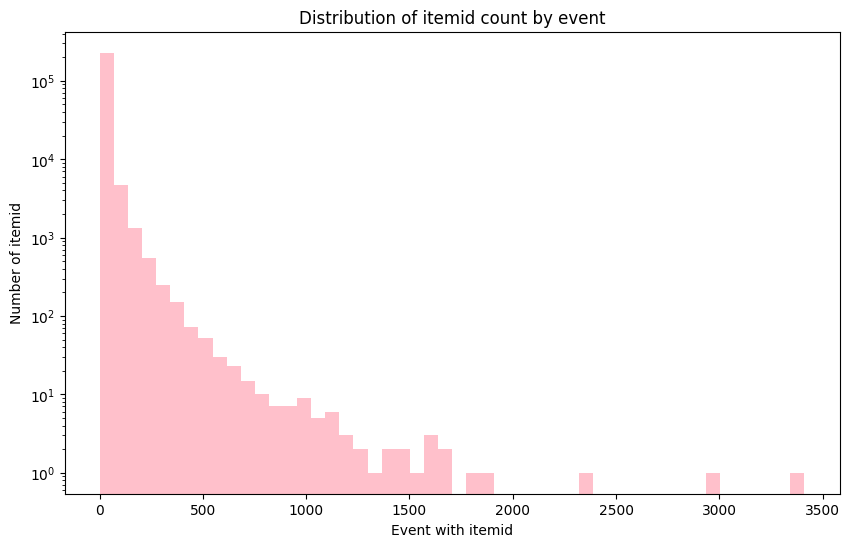

In [23]:
distribution(events,'itemid')

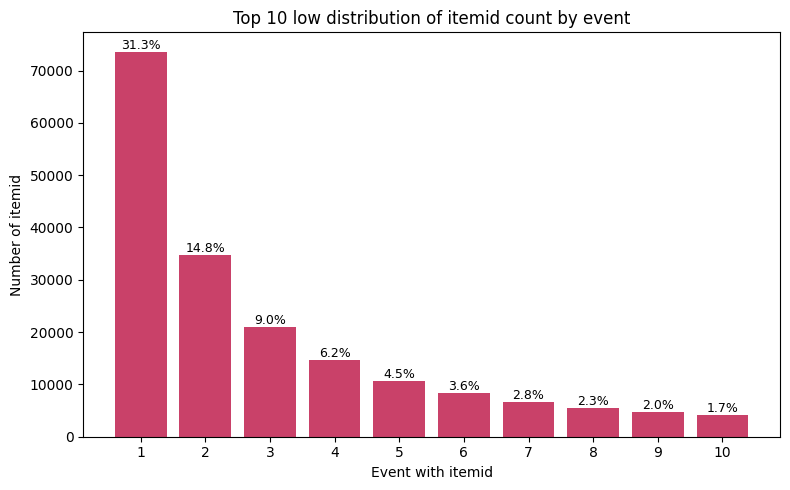

In [24]:
top10_low(events,'itemid')

In [25]:
statistic(events,'itemid')

count    235061.000000
mean         11.723089
std          37.024810
min           1.000000
25%           1.000000
50%           3.000000
75%           9.000000
max        3412.000000
Name: count, dtype: float64


Explore user

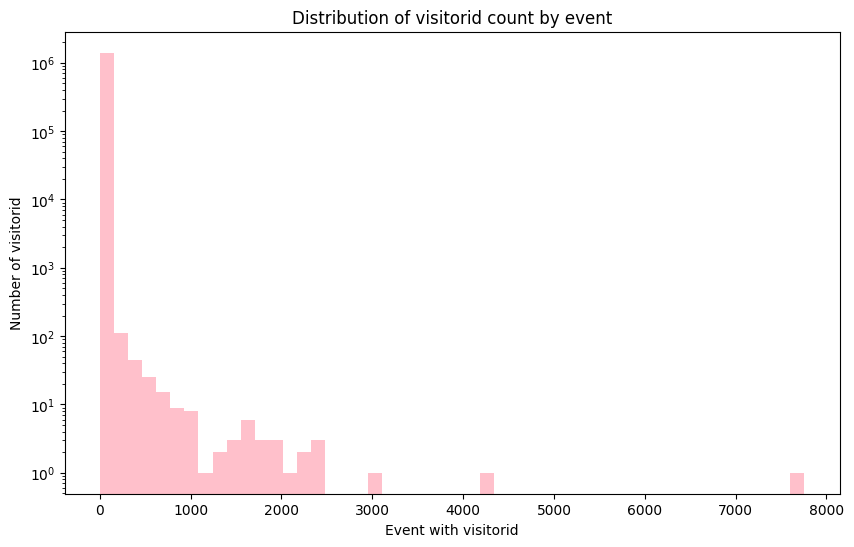

In [26]:
distribution(events,'visitorid')

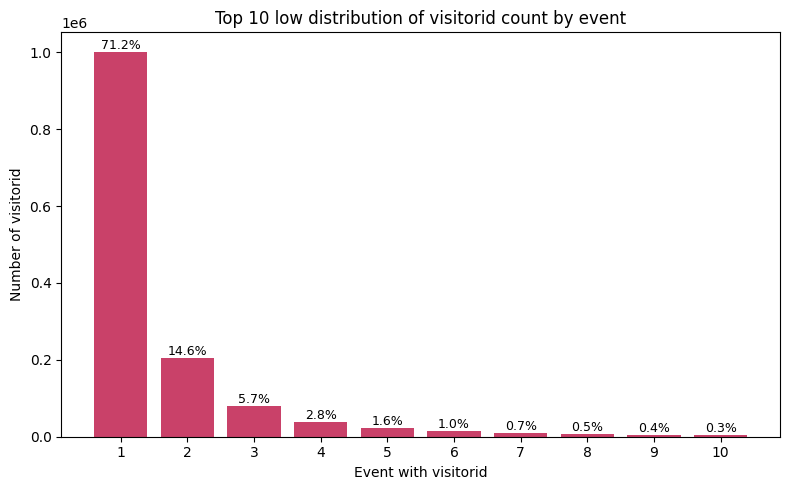

In [27]:
top10_low(events,'visitorid')

In [28]:
statistic(events,'visitorid')

count    1.407580e+06
mean     1.957715e+00
std      1.257981e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: count, dtype: float64


Filter data

In [29]:
# Giữ lại toàn bộ addtocart và transaction
addtocarts = events[events['event'] == 'addtocart']
transactions = events[events['event'] == 'transaction']
# Lấy 10% các event "view"
views = events[events['event'] == 'view'].sample(frac=0.1, random_state=42)
# Gộp lại
final_events = pd.concat([views, addtocarts, transactions]).reset_index(drop=True)
check_info(final_events)
print ( " \ nPercentage of events : " )
print ( final_events['event'].value_counts( normalize = True ) * 100)

<>:9: SyntaxWarning: invalid escape sequence '\ '
<>:9: SyntaxWarning: invalid escape sequence '\ '
C:\Users\Admin\AppData\Local\Temp\ipykernel_4896\529141034.py:9: SyntaxWarning: invalid escape sequence '\ '
  print ( " \ nPercentage of events : " )


The size of events: (357845, 5)
The number of itemid unique: 94202
The number of visitorid unique: 242807
event
view           266422
addtocart       68966
transaction     22457
Name: count, dtype: int64
 \ nPercentage of events : 
event
view           74.451788
addtocart      19.272590
transaction     6.275622
Name: proportion, dtype: float64


In [30]:
from typing_extensions import final
#Lọc K-Core cho đến khi tất cả user và item đều có ít nhất k tương tác
def filter_k_core(data, k_user, k_item):
    print("Start Filtering K-Core...")
    while True:
        user_counts = data['visitorid'].value_counts()
        item_counts = data['itemid'].value_counts()
        remove_users = user_counts[user_counts < k_user].index
        remove_items = item_counts[item_counts < k_item].index
        initial_rows = len(data)
        users_before = data['visitorid'].nunique()
        items_before = data['itemid'].nunique()
        data = data[~data['visitorid'].isin(remove_users)]
        data = data[~data['itemid'].isin(remove_items)]
        if len(remove_users) == 0 and len(remove_items) == 0:
            print("Finish filtering K-Core.")
            break
        print(f"Remove {users_before - data['visitorid'].nunique()} users, {items_before - data['itemid'].nunique()} items, {initial_rows - len(data)} rows.")
    return data

print("\nThe size of dataset before filtering:")
check_info(final_events)
user_counts = final_events['visitorid'].value_counts()
itemid_counts = final_events['itemid'].value_counts()
filtered_events = filter_k_core(final_events.copy(),  user_counts.mean(), itemid_counts.mean())
print("The size of dataset after filtering:")
check_info(filtered_events)


The size of dataset before filtering:
The size of events: (357845, 5)
The number of itemid unique: 94202
The number of visitorid unique: 242807
event
view           266422
addtocart       68966
transaction     22457
Name: count, dtype: int64
Start Filtering K-Core...
Remove 206127 users, 74005 items, 231296 rows.
Remove 7343 users, 8431 items, 20591 rows.
Remove 3077 users, 534 items, 4338 rows.
Remove 443 users, 404 items, 1434 rows.
Remove 236 users, 45 items, 355 rows.
Remove 38 users, 35 items, 129 rows.
Remove 15 users, 2 items, 20 rows.
Remove 3 users, 3 items, 10 rows.
Remove 1 users, 0 items, 1 rows.
Finish filtering K-Core.
The size of dataset after filtering:
The size of events: (99671, 5)
The number of itemid unique: 10743
The number of visitorid unique: 25524
event
view           43075
addtocart      38865
transaction    17731
Name: count, dtype: int64


The data after filtering

The distribution of events after filtering:


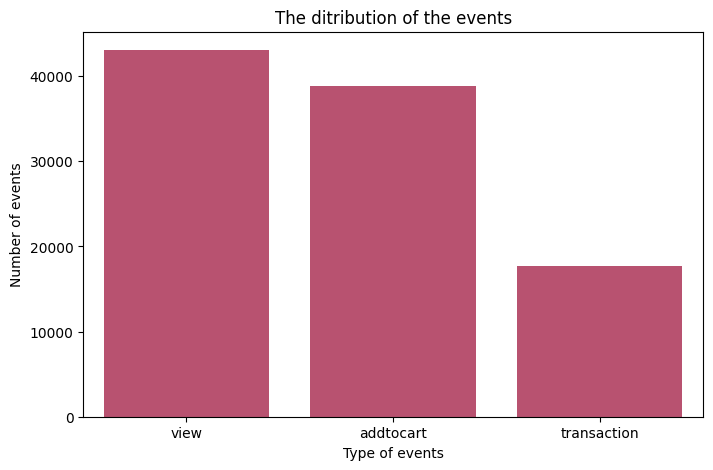

In [31]:
print('The distribution of events after filtering:')
distribution_of_the_events(filtered_events)

The distribution of itemid after filtering:


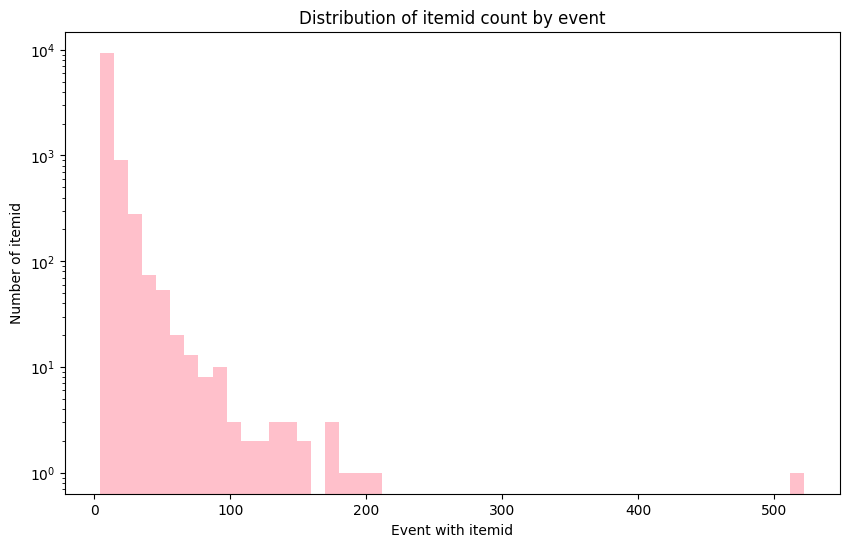

Top 10 low distribution of itemid after filtering:


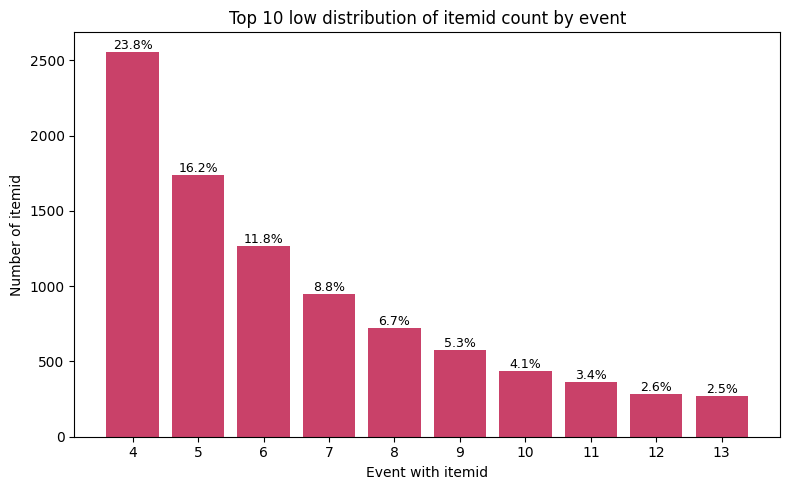

The distribution of visitorid after filtering:


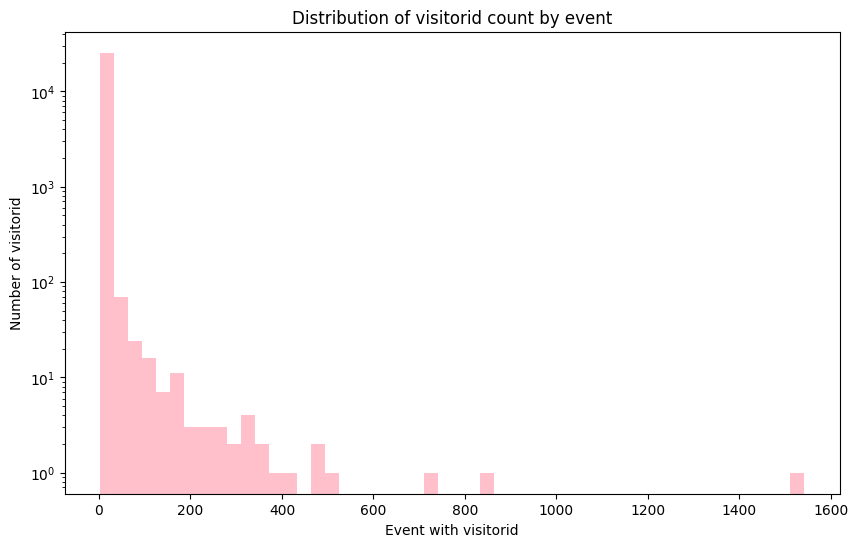

Top 10 low distribution of visitorid after filtering:


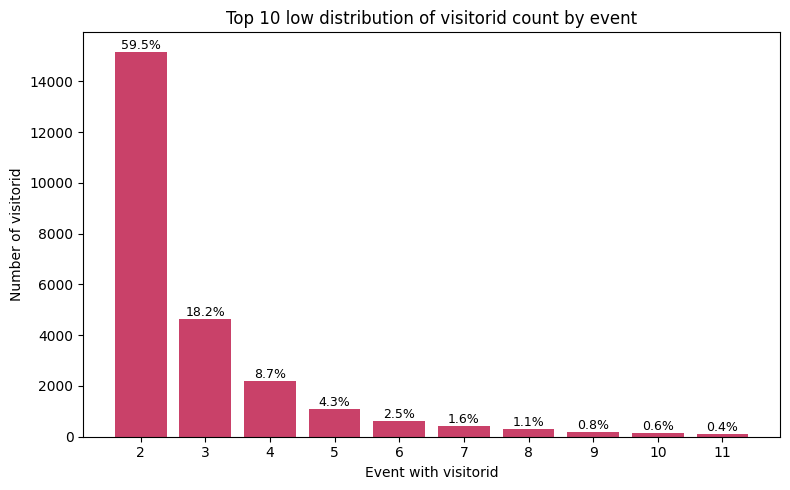

In [32]:
print('The distribution of itemid after filtering:')
distribution(filtered_events,'itemid')
print('Top 10 low distribution of itemid after filtering:')
top10_low(filtered_events,'itemid')
print('The distribution of visitorid after filtering:')
distribution(filtered_events,'visitorid')
print('Top 10 low distribution of visitorid after filtering:')
top10_low(filtered_events,'visitorid')

CÁCH 1: IMPLEMMENT LIGHTGCN NO FEATURE

P2. Implemment LightGCN and evaluate model

In [33]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder

# Chuẩn bị dữ liệu
# Gán trọng số cho từng loại event
event_weight = {
    'view': 1.0,
    'addtocart': 3.0,
    'transaction': 5.0
}
interactions = filtered_events[['visitorid', 'itemid', 'event', 'timestamp']]
interactions = interactions.drop_duplicates(subset=['visitorid', 'itemid', 'event'])
interactions['weight'] = interactions['event'].map(event_weight)

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
interactions['user'] = user_encoder.fit_transform(interactions['visitorid'])
interactions['item'] = item_encoder.fit_transform(interactions['itemid'])

num_users = interactions['user'].nunique()
num_items = interactions['item'].nunique()

In [34]:
interactions.head(3)

,visitorid,itemid,event,timestamp,weight,user,item
1,1172121,374941,view,1435612368758,1.0,21249,8643
11,660953,172959,view,1436187122375,1.0,11868,3896
15,1025012,251594,view,1440127231048,1.0,18534,5742


In [35]:
check_info(interactions)

The size of events: (84453, 7)
The number of itemid unique: 10743
The number of visitorid unique: 25524
event
view           35230
addtocart      32647
transaction    16576
Name: count, dtype: int64


In [36]:
# Sort by user and timestamp
interactions = interactions.sort_values(['user', 'timestamp'])

print("Start splitting with special handling for users with 1 event...")

# Count the number of events for each user
user_event_counts = interactions['user'].value_counts()

# Separate users by the number of events
users_with_1_event = user_event_counts[user_event_counts == 1].index
users_with_2_events = user_event_counts[user_event_counts == 2].index
users_with_3plus_events = user_event_counts[user_event_counts >= 3].index

print(f"Users with 1 event: {len(users_with_1_event)}")
print(f"Users with 2 events: {len(users_with_2_events)}")
print(f"Users with 3+ events: {len(users_with_3plus_events)}")

#  TEST
# Only users with 2+ events can have test data
if len(users_with_2_events) + len(users_with_3plus_events) > 0:
    test_idx = interactions[interactions['user'].isin(user_event_counts[user_event_counts >= 2].index)].groupby('user').tail(1).index
    test_interactions = interactions.loc[test_idx]
else:
    test_interactions = pd.DataFrame(columns=interactions.columns)
    test_idx = pd.Index([])

# Remaining data
remaining_after_test = interactions.drop(test_idx)

# VALIDATION
# Users with 2+ events (after subtracting test) can have validation data
remaining_user_counts = remaining_after_test['user'].value_counts()
users_for_val = remaining_user_counts[remaining_user_counts >= 2].index

if len(users_for_val) > 0:
    val_idx = remaining_after_test[remaining_after_test['user'].isin(users_for_val)].groupby('user').tail(1).index
    val_interactions = remaining_after_test.loc[val_idx]
else:
    val_interactions = pd.DataFrame(columns=interactions.columns)
    val_idx = pd.Index([])

# TRAIN
train_interactions = remaining_after_test.drop(val_idx)

print(f"\nData split results:")
print(f"Train: {len(train_interactions)} interactions, {train_interactions['user'].nunique()} users")
print(f"Validation: {len(val_interactions)} interactions, {val_interactions['user'].nunique()} users")
print(f"Test: {len(test_interactions)} interactions, {test_interactions['user'].nunique()} users")

users_1_event_in_train = set(users_with_1_event) & set(train_interactions['user'].unique())
print(f"Users with 1 event in train: {len(users_1_event_in_train)}")

Start splitting with special handling for users with 1 event...
Users with 1 event: 3530
Users with 2 events: 14019
Users with 3+ events: 7975

Data split results:
Train: 54484 interactions, 25524 users
Validation: 7975 interactions, 7975 users
Test: 21994 interactions, 21994 users
Users with 1 event in train: 3530


In [38]:
# Tính toán và in ra tỷ lệ phần trăm
total_interactions_before_split = len(interactions)
train_percentage = (len(train_interactions) / total_interactions_before_split) * 100
val_percentage = (len(val_interactions) / total_interactions_before_split) * 100
test_percentage = (len(test_interactions) / total_interactions_before_split) * 100

print(f"\nPhân bổ dữ liệu so với bộ dữ liệu trước khi chia:")
print(f"- Train: {len(train_interactions)} tương tác, chiếm {train_percentage:.2f}%")
print(f"- Validation: {len(val_interactions)} tương tác, chiếm {val_percentage:.2f}%")
print(f"- Test: {len(test_interactions)} tương tác, chiếm {test_percentage:.2f}%")


Phân bổ dữ liệu so với bộ dữ liệu trước khi chia:
- Train: 54484 tương tác, chiếm 64.51%
- Validation: 7975 tương tác, chiếm 9.44%
- Test: 21994 tương tác, chiếm 26.04%


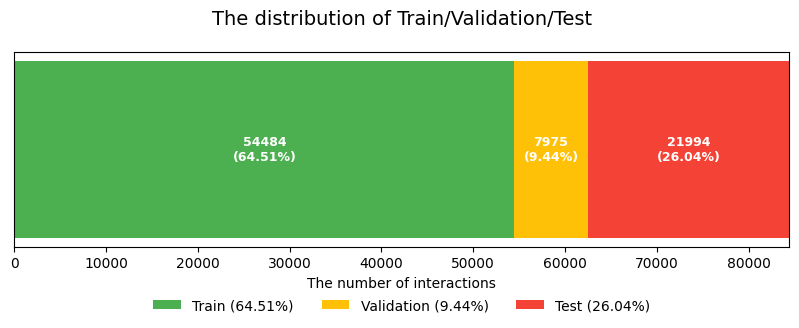

In [40]:

# Dữ liệu
labels = ['Train', 'Validation', 'Test']
sizes = [len(train_interactions), len(val_interactions), len(test_interactions)]
total = sum(sizes)
percentages = [s/total*100 for s in sizes]
colors = ['#4CAF50', '#FFC107', '#F44336']

fig, ax = plt.subplots(figsize=(10, 2.5))

# Vẽ thanh ngang chồng
left = 0
for i, (size, label, color) in enumerate(zip(sizes, labels, colors)):
    ax.barh('Tương tác', size, left=left, label=f'{label} ({percentages[i]:.2f}%)', color=color, height=0.5)
    
    # Thêm văn bản (số lượng và phần trăm)
    text_x = left + size / 2
    ax.text(text_x, 0, f'{size}\n({percentages[i]:.2f}%)', ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    
    left += size

# Tùy chỉnh biểu đồ
ax.set_title('The distribution of Train/Validation/Test', pad=20, fontsize=14)
ax.set_xlim(0, total)
ax.set_xlabel('The number of interactions')
ax.set_yticks([]) # Ẩn trục y vì chỉ có một thanh
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3, frameon=False)

# Điều chỉnh khoảng trống dưới cùng để tránh chồng chéo
plt.subplots_adjust(bottom=0.1)
plt.show()

In [ ]:
# Tạo edge_index và edge_weight cho train
user_indices = torch.tensor(train_interactions['user'].values, dtype=torch.long)
item_indices = torch.tensor(train_interactions['item'].values, dtype=torch.long) + num_users
edge_weight = torch.tensor(train_interactions['weight'].values, dtype=torch.float)

edge_index = torch.cat([
    torch.stack([user_indices, item_indices]),
    torch.stack([item_indices, user_indices])
], dim=1)
edge_weight = torch.cat([edge_weight, edge_weight])

In [ ]:
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=128 , n_layers=2):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.n_layers = n_layers
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)
        self.alpha = nn.Parameter(torch.ones(self.n_layers + 1) / (self.n_layers + 1))

    def forward(self, edge_index, edge_weight):
        all_embeddings = torch.cat([self.user_embedding.weight, self.item_embedding.weight])
        embeddings_list = [all_embeddings]
        for _ in range(self.n_layers):
            all_embeddings = self.propagate(edge_index, edge_weight, all_embeddings)
            embeddings_list.append(all_embeddings)
           # Học trọng số layer combination
        import torch.nn.functional as F
        weights = F.softmax(self.alpha, dim=0)  # [n_layers+1]
        stacked = torch.stack(embeddings_list, dim=1) # [num_nodes, n_layers+1, emb_dim]
        final_embedding = (stacked * weights[None, :, None]).sum(dim=1)
        user_emb, item_emb = torch.split(final_embedding, [self.num_users, self.num_items])
        return user_emb, item_emb
    def propagate(self, edge_index, edge_weight, embeddings):
        row, col = edge_index
        deg = torch.bincount(row, minlength=embeddings.size(0)).float()
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col] * edge_weight
        agg = torch.zeros_like(embeddings)
        agg.index_add_(0, row, embeddings[col] * norm.unsqueeze(1))
        return agg



In [ ]:
def bpr_loss_reg(user_emb, pos_emb, neg_emb, reg_weight=1e-4):
    pos_scores = (user_emb * pos_emb).sum(dim=1)
    neg_scores = (user_emb * neg_emb).sum(dim=1)
    bpr = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
    reg = (user_emb.norm(2).pow(2) + pos_emb.norm(2).pow(2) + neg_emb.norm(2).pow(2)) / user_emb.size(0) / 3
    return bpr + reg_weight * reg

In [ ]:
# Chuẩn bị dữ liệu sampling
unique_users_in_train = train_interactions['user'].unique()
user_pos_items_dict = train_interactions.groupby('user')['item'].apply(set).to_dict()
item_counts = train_interactions['item'].value_counts()
full_item_counts = item_counts.reindex(np.arange(num_items), fill_value=1)
sampling_probs = np.power(full_item_counts.values, 0.75)
sampling_probs /= np.sum(sampling_probs)
item_indices_for_sampling = full_item_counts.index.values
print("Hoàn tất.")

def sample_batch_popularity(batch_size, users_to_sample, pos_dict, pop_item_indices, pop_item_probs):
    users = np.random.choice(users_to_sample, size=batch_size, replace=True)
    pos_items, neg_items = [], []
    for u in users:
        user_pos_set = pos_dict.get(u, set())
        if not user_pos_set:
            pos_items.append(np.random.randint(0, num_items))
            neg_items.append(np.random.randint(0, num_items))
            continue
        pos_item = np.random.choice(list(user_pos_set))
        pos_items.append(pos_item)
        while True:
            neg_item = np.random.choice(pop_item_indices, p=pop_item_probs)
            if neg_item not in user_pos_set:
                neg_items.append(neg_item)
                break
    return torch.LongTensor(users), torch.LongTensor(pos_items), torch.LongTensor(neg_items)

Hoàn tất.


In [ ]:
#  Đánh giá model bằng HR@20, NDCG@20
def evaluate_lightgcn(model, train_interactions, test_interactions, edge_index, edge_weight, K=20):
    model.eval()
    user_emb, item_emb = model(edge_index, edge_weight)
    user_emb = user_emb.cpu().detach().numpy()
    item_emb = item_emb.cpu().detach().numpy()
    hits, ndcgs = [], []
    user2train_items = train_interactions.groupby('user')['item'].apply(set).to_dict()
    user2test_item = test_interactions.set_index('user')['item'].to_dict()
    for user in user2test_item:
        test_item = user2test_item[user]
        train_items = user2train_items.get(user, set())
        scores = np.dot(user_emb[user], item_emb.T)
        scores[list(train_items)] = -np.inf
        top_k = np.argpartition(scores, -K)[-K:]
        top_k = top_k[np.argsort(-scores[top_k])]
        hit = int(test_item in top_k)
        hits.append(hit)
        if test_item in top_k:
            rank = np.where(top_k == test_item)[0][0] + 1
            ndcg = 1 / np.log2(rank + 1)
        else:
            ndcg = 0
        ndcgs.append(ndcg)
    hr = np.mean(hits)
    ndcg = np.mean(ndcgs)
    print(f"HR@{K}: {hr:.4f}, NDCG@{K}: {ndcg:.4f}")
    return hr, ndcg

In [ ]:
# THỬ NGHIỆM
architectures_to_test = [2,3]
results = {}
best_overall_model_state = None
winning_architecture_hr = -1
best_n_layers = 0
best_epoch = 0
training_history = {}
K = 20
embedding_dim = 256

print("Bắt đầu thử nghiệm và tìm kiến trúc tốt nhất...\n")

for n_layers in architectures_to_test:
    print(f"=============== TESTING ARCHITECTURE: n_layers = {n_layers} ===============")
    training_history[n_layers] = {
        'epochs': [],
        'losses': [],
        'hr_scores': [],
        'ndcg_scores': []
    }

    #  Khởi tạo model và optimizer mới
    model = LightGCN(num_users, num_items, embedding_dim, n_layers=n_layers)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
       # Khởi tạo lưu trữ cho kiến trúc này

    #  Khởi tạo tham số cho Early Stopping
    patience = 7
    wait = 0
    best_hr_for_this_arch = 0
    best_model_state_for_this_arch = None
    best_epoch_for_this_arch = 0

    epochs = 30
    batch_size = 1024
    num_batches_per_epoch = len(train_interactions) // batch_size if len(train_interactions) > batch_size else 1

    #  Vòng lặp huấn luyện với Early Stopping
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for _ in range(num_batches_per_epoch):
            users, pos_items, neg_items = sample_batch_popularity(batch_size, unique_users_in_train, user_pos_items_dict, item_indices_for_sampling, sampling_probs)
            user_emb, item_emb = model(edge_index, edge_weight)
            u_emb, pos_emb, neg_emb = user_emb[users], item_emb[pos_items], item_emb[neg_items]

            optimizer.zero_grad()
            loss = bpr_loss_reg(u_emb, pos_emb, neg_emb, reg_weight=1e-4)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / num_batches_per_epoch if num_batches_per_epoch > 0 else 0
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

        # Đánh giá trên tập validation
        print("Đánh giá trên tập validation...")
        hr, ndcg = evaluate_lightgcn(model, train_interactions, val_interactions, edge_index, edge_weight, K=K)
         # LƯU DỮ LIỆU VÀO LỊCH SỬ
        training_history[n_layers]['epochs'].append(epoch + 1)
        training_history[n_layers]['losses'].append(avg_loss)
        training_history[n_layers]['hr_scores'].append(hr)
        training_history[n_layers]['ndcg_scores'].append(ndcg)
        if hr > best_hr_for_this_arch:
            best_hr_for_this_arch = hr
            best_epoch_for_this_arch = epoch + 1
            wait = 0
            best_model_state_for_this_arch = model.state_dict()
            print(f"--> Validation HR cải thiện: {best_hr_for_this_arch:.4f} tại epoch {best_epoch_for_this_arch}. Đã lưu model tạm thời.")
        else:
            wait += 1
            if wait >= patience:
                print(f"--> Validation HR không cải thiện trong {patience} epochs. EARLY STOPPING!")
                break


    results[n_layers] = (best_hr_for_this_arch, best_epoch_for_this_arch)
    print(f"Kết quả tốt nhất với n_layers = {n_layers}: HR@{K} = {best_hr_for_this_arch:.4f} tại epoch {best_epoch_for_this_arch}")

    # Cập nhật kiến trúc tốt nhất tổng thể
    if best_hr_for_this_arch > winning_architecture_hr:
        print(f"*** Tìm thấy kiến trúc tốt hơn! (HR cũ: {winning_architecture_hr:.4f}) ***")
        winning_architecture_hr = best_hr_for_this_arch
        best_overall_model_state = best_model_state_for_this_arch
        best_n_layers = n_layers
        best_epoch = best_epoch_for_this_arch

print("\n\n=============== KẾT QUẢ THỬ NGHIỆM ===============")
for n_layers_key, (hr_val, epoch_val) in results.items():
    print(f"n_layers={n_layers_key}: Best Validation HR@{K} = {hr_val:.4f} tại epoch {epoch_val}")

print(f"\n==> KIẾN TRÚC CHIẾN THẮNG LÀ: n_layers = {best_n_layers} với HR@{K} = {winning_architecture_hr:.4f} tại epoch {best_epoch} trên tập validation.")

# ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST (KHÔNG CẦN HUẤN LUYỆN LẠI) ---
print("\n=============== ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ===============")
print("Load lại model tốt nhất từ quá trình early stopping để đánh giá...")

#  Khởi tạo model với kiến trúc chiến thắng
final_model = LightGCN(num_users, num_items, embedding_dim, n_layers=best_n_layers)
if best_overall_model_state:
    final_model.load_state_dict(best_overall_model_state)
    # Gán biến 'model' để các cell sau có thể dùng nếu cần
    model = final_model
    print(f"Đã load thành công model với n_layers = {best_n_layers}.")
else:
    print("Lỗi: Không tìm thấy trạng thái model tốt nhất để load.")
    final_model = None



Bắt đầu thử nghiệm và tìm kiến trúc tốt nhất...

=============== TESTING ARCHITECTURE: n_layers = 2 ===============
Epoch 1/30, Loss: 0.6430
Đánh giá trên tập validation...
HR@20: 0.0399, NDCG@20: 0.0237
--> Validation HR cải thiện: 0.0399 tại epoch 1. Đã lưu model tạm thời.
Epoch 2/30, Loss: 0.5250
Đánh giá trên tập validation...
HR@20: 0.0508, NDCG@20: 0.0304
--> Validation HR cải thiện: 0.0508 tại epoch 2. Đã lưu model tạm thời.
Epoch 3/30, Loss: 0.4035
Đánh giá trên tập validation...
HR@20: 0.0568, NDCG@20: 0.0334
--> Validation HR cải thiện: 0.0568 tại epoch 3. Đã lưu model tạm thời.
Epoch 4/30, Loss: 0.3117
Đánh giá trên tập validation...
HR@20: 0.0603, NDCG@20: 0.0352
--> Validation HR cải thiện: 0.0603 tại epoch 4. Đã lưu model tạm thời.
Epoch 5/30, Loss: 0.2493
Đánh giá trên tập validation...
HR@20: 0.0619, NDCG@20: 0.0362
--> Validation HR cải thiện: 0.0619 tại epoch 5. Đã lưu model tạm thời.
Epoch 6/30, Loss: 0.2035
Đánh giá trên tập validation...
HR@20: 0.0627, NDCG@20: 0.0

In [ ]:
if final_model:
    print("\nBắt đầu đánh giá trên tập test...")
    # Gọi hàm đánh giá
    evaluate_lightgcn(final_model, train_interactions, test_interactions, edge_index, edge_weight, K=K)


Bắt đầu đánh giá trên tập test...
HR@20: 0.0451, NDCG@20: 0.0248


2 layers: Best HR=0.0651 (epoch 9)
3 layers: Best HR=0.0632 (epoch 11)


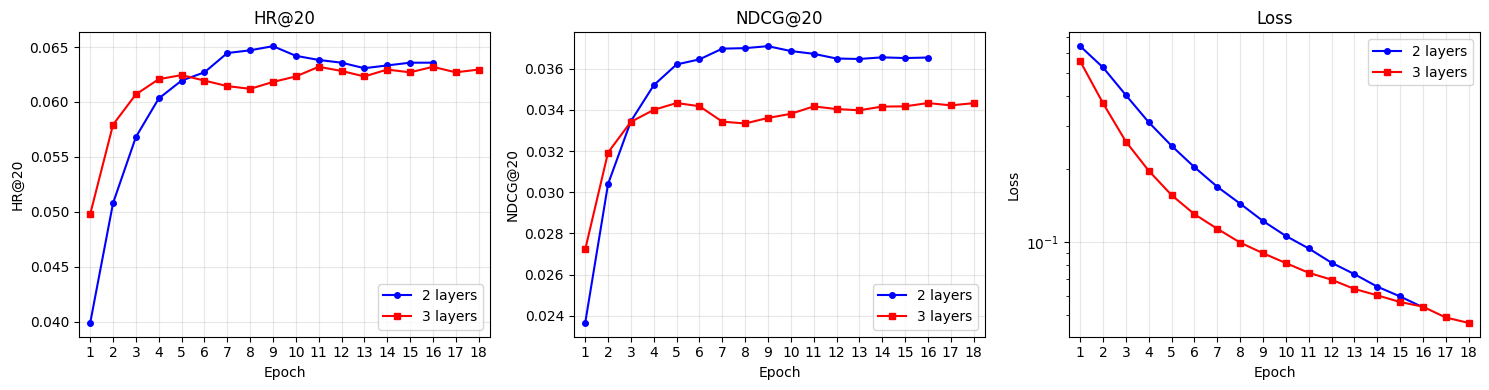


 Winner: 2 layers với HR@20=0.0651


In [ ]:
# VẼ ĐỒ THỊ TRAINING PROGRESS
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
colors = ['blue', 'red', 'green', 'orange']
markers = ['o', 's', '^', 'D']

best_hr_overall = 0
best_arch = None

for i, (n_layers, data) in enumerate(training_history.items()):
    color = colors[i]
    marker = markers[i]
    epochs, hr, ndcg, loss = data['epochs'], data['hr_scores'], data['ndcg_scores'], data['losses']
    ax1.plot(epochs, hr, color=color, marker=marker, label=f'{n_layers} layers', markersize=4, linestyle='-')
    ax2.plot(epochs, ndcg, color=color, marker=marker, label=f'{n_layers} layers', markersize=4, linestyle='-')
    ax3.plot(epochs, loss, color=color, marker=marker, label=f'{n_layers} layers', markersize=4, linestyle='-')
    best_hr = max(hr)
    if best_hr > best_hr_overall:
        best_hr_overall, best_arch = best_hr, n_layers

    print(f"{n_layers} layers: Best HR={best_hr:.4f} (epoch {epochs[hr.index(best_hr)]})")

for ax, title, ylabel in zip([ax1, ax2, ax3],
                            ['HR@20', 'NDCG@20', 'Loss'],
                            ['HR@20', 'NDCG@20', 'Loss']):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
    all_epochs = []
    for data in training_history.values():
        all_epochs.extend(data['epochs'])

    if all_epochs:
        min_epoch = min(all_epochs)
        max_epoch = max(all_epochs)
        epoch_ticks = list(range(min_epoch, max_epoch + 1, max(1, (max_epoch - min_epoch) // 10)))
        if max_epoch not in epoch_ticks:
            epoch_ticks.append(max_epoch)

        ax.set_xticks(epoch_ticks)
        ax.set_xlim(min_epoch - 0.5, max_epoch + 0.5)

ax3.set_yscale('log')
plt.tight_layout()
plt.show()

print(f"\n Winner: {best_arch} layers với HR@20={best_hr_overall:.4f}")


P3.Qualitative Evaluation and Sample Recommendation Generation

In [ ]:
def recommend_top_k(model, user_id, k):
    model.eval()
    with torch.no_grad():
        user_emb, item_emb = model(edge_index, edge_weight)
        u_idx = user_encoder.transform([user_id])[0]
        scores = (user_emb[u_idx] @ item_emb.t()).cpu().numpy()
        top_k = np.argsort(-scores)[:k]
        return item_encoder.inverse_transform(top_k)

In [ ]:
user_to_check = test_interactions['visitorid'].iloc[5]
user_internal_id = user_encoder.transform([user_to_check])[0]
ground_truth_item = test_interactions[test_interactions['visitorid'] == user_to_check]['itemid'].iloc[0]
recommendations = recommend_top_k(final_model, user_to_check, k=20)
print(f"Top 20 item được gợi ý: {list(recommendations)}")
if ground_truth_item in recommendations:
    print("\n==> THÀNH CÔNG: Mô hình đã dự đoán đúng item 'đáp án' !")
else:
    print("\n==> THẤT BẠI: Mô hình đã không dự đoán đúng item 'đáp án' ")


Top 20 item được gợi ý: [np.int64(16344), np.int64(349470), np.int64(303229), np.int64(395273), np.int64(173365), np.int64(187848), np.int64(153874), np.int64(23055), np.int64(268006), np.int64(132423), np.int64(357779), np.int64(55239), np.int64(289160), np.int64(304558), np.int64(372617), np.int64(178480), np.int64(442721), np.int64(80085), np.int64(5951), np.int64(198954)]

==> THÀNH CÔNG: Mô hình đã dự đoán đúng item 'đáp án' !
